In [ ]:
import os
import time
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import jax.numpy as jnp
import optax
from jax.scipy.spatial.transform import Rotation
from orbax.checkpoint import PyTreeCheckpointer
from flax.training.train_state import TrainState
from matplotlib import pyplot as plt

from lotf import LOTF_PATH
from lotf.envs import HoveringStateEnv, rollout
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import (
    MLP,
    LatentConditionedResidualDynamics,
    RecurrentTrajectoryEncoder,
)
from lotf.objects import Quadrotor

%matplotlib inline

# Joint Training of the Trajectory Encoder and Residual Dynamics

## 1. Seed

In [ ]:
seed = 0
master_key = jax.random.key(seed)

# Give every stochastic stage its own reproducible stream. Unlike repeatedly
# splitting one mutable notebook key, these keys do not depend on cell reruns.
def experiment_key(stream_id):
    return jax.random.fold_in(master_key, stream_id)

key = master_key  # Kept only for compatibility with exploratory cells.

## 2. Define Simulation Dynamics Config

In [ ]:
# simulation dynamics config
sim_dyn_config = {
    "use_high_fidelity": False,           # stand-in for the disturbed/real system
    "use_forward_residual": False,       # whether to use residual dynamics in forward simulation
}

# No residual parameters are read when use_forward_residual=False. Passing an
# empty pytree avoids restoring the legacy CUDA-sharded dummy checkpoint.
dummy_residual_params = {}

## 3. Create Quadrotor Object and Data-Collection Environment

In [ ]:
# simulation parameters
sim_dt = 0.02
max_sim_time = 5.0

# quadrotor object
quad_obj = Quadrotor.from_name("example_quad", sim_dyn_config)

eval_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,  # equation (2): v_dot += w
)
eval_env = MinMaxObservationWrapper(eval_env)

# get dims
action_dim = eval_env.action_space.shape[0]
obs_dim = eval_env.observation_space.shape[0]

print("====== eval_env info ======")
print(f"action_dim: {action_dim}")
print(f"obs_dim: {obs_dim}")

## 4. Load the Trained Policy

In [ ]:
policy_name = "state_hovering_params"

# create policy network
base_policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    action_bias=eval_env.hovering_action,
)

path = LOTF_PATH + "/../checkpoints/policy/" + policy_name
ckptr = PyTreeCheckpointer()
base_policy_params = ckptr.restore(path)
# define policy function
def policy_trained(obs, key):
    return base_policy_net.apply(base_policy_params, obs)

## 5. Collect Rollouts with Fixed Wind Acceleration

In [985]:
# HoveringStateEnv samples one row from wind_z_table.csv at reset. We retain
# the sampled wind acceleration for the whole rollout but ignore the paired
# CSV latent completely: the encoder must infer its own condition online.
num_rollouts = 2048
key_rollouts = experiment_key(1)
rollout_keys = jax.random.split(key_rollouts, num_rollouts)
parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None, None))
trajectories = parallel_rollout(
    eval_env, rollout_keys, policy_trained, dummy_residual_params
)

env_states = trajectories.state
quad_states = env_states.quadrotor_state

# Convert rotation matrices to the paper's state convention: (p, q, v).
def state_vectors(position, rotation_matrix, velocity):
    quaternion_xyzw = Rotation.from_matrix(rotation_matrix).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]], axis=-1
    )
    return jnp.concatenate([position, quaternion_wxyz, velocity], axis=-1)

states = state_vectors(
    quad_states.p[:, :-1], quad_states.R[:, :-1], quad_states.v[:, :-1]
)
# The action chosen from s_t is stored at the end of the successor state's
# action buffer, hence the 1: alignment below.
actions = env_states.last_actions[:, 1:, -1, :]
hidden_acceleration = env_states.hidden_acceleration[:, :-1, :]
state_actions = jnp.concatenate([states, actions], axis=-1)

# rollout(..., real_step=False) does not auto-reset. Keep the terminal
# transition itself, but discard any subsequent out-of-episode transitions.
done = jnp.logical_or(
    trajectories.terminated[:, 1:], trajectories.truncated[:, 1:]
)
valid_transition = (jnp.cumsum(done, axis=1) - done) == 0

assert states.shape[-1] == 10
assert actions.shape[-1] == 4
assert state_actions.shape[-1] == 14
assert jnp.all(hidden_acceleration == hidden_acceleration[:, :1, :])

_, rollouts_per_condition = jnp.unique(
    hidden_acceleration[:, 0, :], axis=0, return_counts=True
)
print(f"Collected {valid_transition.sum():,} valid transitions")
print(f"Conditions represented: {rollouts_per_condition.shape[0]}/17")
print(f"Rollouts per represented condition: {rollouts_per_condition}")

Collected 512,000 valid transitions
Conditions represented: 17/17
Rollouts per represented condition: [114 103 131 129 130 115 128 148 142  96 123 115 128 129 102 111 104]


## 6. Build Non-Overlapping Latent Groups and Residual Targets

In [988]:
# Infer one latent from a 20-step context and share it across the following
# dynamics_horizon transitions. Advance each group by dynamics_horizon so a
# target transition is never assigned to multiple different latent codes.
context_length = 20
dynamics_horizon = 220
train_fraction = 0.9

num_transitions_per_rollout = state_actions.shape[1]
num_groups_per_rollout = (
    num_transitions_per_rollout - context_length
) // dynamics_horizon
assert num_groups_per_rollout > 0
group_start_indices = (
    jnp.arange(num_groups_per_rollout) * dynamics_horizon
)

# Split whole rollouts before normalization or grouping. Groups from a rollout
# can therefore never appear in both training and validation.
key_split = experiment_key(2)
rollout_permutation = jax.random.permutation(key_split, num_rollouts)
num_train_rollouts = int(train_fraction * num_rollouts)
train_rollout_indices = rollout_permutation[:num_train_rollouts]
train_rollout_mask = jnp.zeros(num_rollouts, dtype=bool)
train_rollout_mask = train_rollout_mask.at[train_rollout_indices].set(True)

normalization_mask = train_rollout_mask[:, None] & valid_transition
input_mean = state_actions[normalization_mask].mean(axis=0)
input_std = jnp.maximum(
    state_actions[normalization_mask].std(axis=0), 1e-6
)
normalized_state_actions = (state_actions - input_mean) / input_std

context_transition_indices = (
    group_start_indices[:, None]
    + jnp.arange(context_length)[None, :]
)
target_transition_indices = (
    group_start_indices[:, None]
    + context_length
    + jnp.arange(dynamics_horizon)[None, :]
)
assert jnp.unique(target_transition_indices).size == (
    num_groups_per_rollout * dynamics_horizon
)

grouped_contexts = normalized_state_actions[:, context_transition_indices]
grouped_dynamics_inputs = normalized_state_actions[:, target_transition_indices]
context_valid = valid_transition[:, context_transition_indices].all(axis=-1)
targets_valid = valid_transition[:, target_transition_indices].all(axis=-1)
valid_context = context_valid & targets_valid

contexts = grouped_contexts[valid_context]
dynamics_inputs = grouped_dynamics_inputs[valid_context]
context_rollout_grid = jnp.broadcast_to(
    jnp.arange(num_rollouts)[:, None], valid_context.shape
)
context_time_grid = jnp.broadcast_to(
    (group_start_indices + context_length)[None, :],
    valid_context.shape,
)
context_rollout_ids = context_rollout_grid[valid_context]
context_times = context_time_grid[valid_context]

# Evaluate the nominal rigid-body prior on every target transition. Its delay
# remains identical to the data-collection environment.
prior_dyn_config = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
prior_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=Quadrotor.from_name("example_quad", prior_dyn_config),
    apply_hidden_acceleration=False,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)

transition_states = jax.tree.map(
    lambda leaf: leaf[:, :num_transitions_per_rollout].reshape(
        (-1,) + leaf.shape[2:]
    ),
    env_states,
)
observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf[:, 1:num_transitions_per_rollout + 1].reshape(
        (-1,) + leaf.shape[2:]
    ),
    quad_states,
)
prior_actions = actions.reshape(-1, action_dim)
key_prior = experiment_key(3)
prior_keys = jax.random.split(key_prior, prior_actions.shape[0])

@jax.jit
def evaluate_prior(prior_states, prior_actions, prior_keys):
    def prior_step(state, action, step_key):
        transition = prior_env._step(state, action, {}, step_key)
        return transition.state.quadrotor_state

    return jax.vmap(prior_step)(prior_states, prior_actions, prior_keys)

# Evaluate each physical transition once in fixed-size batches to bound
# device memory during nominal-prior construction.
prior_batch_size = 2048
num_prior_transitions = prior_actions.shape[0]
num_padded_prior_transitions = (
    (num_prior_transitions + prior_batch_size - 1) // prior_batch_size
    * prior_batch_size
)
prior_padding_indices = jnp.minimum(
    jnp.arange(num_padded_prior_transitions),
    num_prior_transitions - 1,
)
padded_transition_states = jax.tree.map(
    lambda leaf: leaf[prior_padding_indices], transition_states
)
padded_prior_actions = prior_actions[prior_padding_indices]
padded_prior_keys = prior_keys[prior_padding_indices]
prior_output_chunks = []
for batch_start in range(0, num_padded_prior_transitions, prior_batch_size):
    batch_stop = batch_start + prior_batch_size
    prior_output_chunks.append(evaluate_prior(
        jax.tree.map(
            lambda leaf: leaf[batch_start:batch_stop],
            padded_transition_states,
        ),
        padded_prior_actions[batch_start:batch_stop],
        padded_prior_keys[batch_start:batch_stop],
    ))
prior_next_quad_states = jax.tree.map(
    lambda *chunks: jnp.concatenate(chunks, axis=0)[:num_prior_transitions],
    *prior_output_chunks,
)

def state_difference(observed, nominal):
    # Hovering predicts translational residuals only. Orientation is advanced
    # entirely by the analytical body-rate dynamics in the physics prior.
    return jnp.concatenate(
        [observed.p - nominal.p, observed.v - nominal.v], axis=-1
    )

transition_residual_targets = state_difference(
    observed_next_quad_states, prior_next_quad_states
).reshape(num_rollouts, num_transitions_per_rollout, -1)
residual_targets = (
    transition_residual_targets[:, target_transition_indices][valid_context]
)
assert residual_targets.shape[-1] == 6

training_context_mask = train_rollout_mask[context_rollout_ids]
train_contexts = contexts[training_context_mask]
train_dynamics_inputs = dynamics_inputs[training_context_mask]
train_targets = residual_targets[training_context_mask]
validation_contexts = contexts[~training_context_mask]
validation_dynamics_inputs = dynamics_inputs[~training_context_mask]
validation_targets = residual_targets[~training_context_mask]
validation_rollout_ids = context_rollout_ids[~training_context_mask]
validation_context_times = context_times[~training_context_mask]
train_targets.block_until_ready()
validation_targets.block_until_ready()
del grouped_contexts, grouped_dynamics_inputs, normalized_state_actions
del transition_states, observed_next_quad_states, prior_next_quad_states
del padded_transition_states, padded_prior_actions, padded_prior_keys
del prior_output_chunks, transition_residual_targets, prior_padding_indices
jax.clear_caches()
print(f"Training rollouts:   {num_train_rollouts}")
print(f"Validation rollouts: {num_rollouts - num_train_rollouts}")
print(f"Training contexts:   {train_contexts.shape[0]:,}")
print(f"Validation contexts: {validation_contexts.shape[0]:,}")
print(f"Complete latent groups per full rollout: {num_groups_per_rollout}")
print(f"Context shape:       {train_contexts.shape[1:]}")
print(f"Targets per latent:  {dynamics_horizon}")
print(
    "Incomplete tail transitions discarded per full rollout: "
    f"{(num_transitions_per_rollout - context_length) % dynamics_horizon}"
)


Training rollouts:   1843
Validation rollouts: 205
Training contexts:   1,843
Validation contexts: 205
Complete latent groups per full rollout: 1
Context shape:       (20, 14)
Targets per latent:  220
Incomplete tail transitions discarded per full rollout: 10


## 7. Create the Encoder, Decoder, and FiLM Residual Dynamics

In [986]:
state_action_dim = state_actions.shape[-1]
latent_dim = 12

trajectory_encoder = RecurrentTrajectoryEncoder(
    state_action_dim=state_action_dim,
    context_length=context_length,
    latent_dim=latent_dim,
    projection_dim=128,
    hidden_dim=128,
)
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=state_action_dim,
    latent_dim=latent_dim,
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=False,
)
# G_eta is auxiliary: it reconstructs the complete normalized context from z.
context_decoder = MLP(
    [latent_dim, 256, 256, context_length * state_action_dim],
    nonlinearity=jax.nn.gelu,
)

key_encoder, key_residual, key_decoder = jax.random.split(
    experiment_key(4), 3
)
initial_joint_params = {
    "encoder": trajectory_encoder.initialize(key_encoder),
    "residual": residual_model.initialize(key_residual),
    "decoder": context_decoder.initialize(key_decoder),
}

def joint_forward(params, contexts, normalized_dynamics_inputs):
    latents = trajectory_encoder.apply(params["encoder"], contexts)
    expanded_latents = jnp.broadcast_to(
        latents[..., None, :],
        normalized_dynamics_inputs.shape[:-1] + (latent_dim,),
    )
    predicted_residuals = residual_model.apply(
        params["residual"], normalized_dynamics_inputs, expanded_latents
    )
    reconstructed_contexts = context_decoder.apply(
        params["decoder"], latents
    ).reshape(contexts.shape)
    return latents, predicted_residuals, reconstructed_contexts

dummy_latent, dummy_residuals, dummy_reconstruction = joint_forward(
    initial_joint_params, train_contexts[0], train_dynamics_inputs[0]
)
assert dummy_latent.shape == (latent_dim,)
assert dummy_residuals.shape == (dynamics_horizon, 6)
assert dummy_reconstruction.shape == (context_length, state_action_dim)
print(f"Encoder output:        {dummy_latent.shape}")
print(f"Residual-head output: {dummy_residuals.shape}")
print(f"Decoder output:        {dummy_reconstruction.shape}")


Encoder output:        (12,)
Residual-head output: (220, 6)
Decoder output:        (20, 14)


## 8. Joint Training with Normalized Residual Targets

In [ ]:
# Compute target statistics from training rollouts only. Each of the six output
# coordinates is standardized independently; validation data never contributes.
# lambda_rec is exposed explicitly because the paper does not prescribe one
# universal task-independent value. L_rec acts on normalized context channels.
lambda_rec = 1e-7
huber_delta = 1
batch_size = min(128, train_contexts.shape[0])
num_training_steps = 40000
steps_per_training_chunk = 100
print_every = 100  # Set to 1 to print every optimizer update.
assert num_training_steps % steps_per_training_chunk == 0

residual_target_mean = train_targets.mean(axis=(0, 1))
residual_target_std = jnp.maximum(
    train_targets.std(axis=(0, 1)), 1e-8
)
normalized_train_targets = (
    train_targets - residual_target_mean
) / residual_target_std
normalized_validation_targets = (
    validation_targets - residual_target_mean
) / residual_target_std

component_names = [
    "delta_p_x", "delta_p_y", "delta_p_z",
    "delta_v_x", "delta_v_y", "delta_v_z",
]

print("Training residual-target statistics:")
for name, mean, std in zip(
    component_names, residual_target_mean, residual_target_std
):
    print(f"  {name:>10s}: mean={mean:.6e}, std={std:.6e}")

# Initialize the target-normalized encoder, residual dynamics, and decoder.
target_normalized_train_state = TrainState.create(
    apply_fn=joint_forward,
    params=initial_joint_params,
    tx=optax.adam(learning_rate=3e-4),
)

def target_normalized_joint_loss(
    params, contexts, dynamics_inputs, normalized_targets
):
    _, normalized_predictions, reconstructions = joint_forward(
        params, contexts, dynamics_inputs
    )
    dynamics_loss = optax.huber_loss(
        normalized_predictions, normalized_targets, delta=huber_delta
    ).mean()
    # Equation (16): average the per-context squared L2 norm. Sum over
    # context time and feature dimensions, then average over the batch.
    reconstruction_loss = jnp.sum(
        jnp.square(reconstructions - contexts), axis=(-2, -1)
    ).mean()
    total_loss = dynamics_loss + lambda_rec * reconstruction_loss
    return total_loss, (dynamics_loss, reconstruction_loss)

@jax.jit
def train_target_normalized_chunk(train_state, rng_key, first_step):
    def training_step(carry, step):
        state, step_key = carry
        step_key, sample_key = jax.random.split(step_key)
        batch_indices = jax.random.randint(
            sample_key, (batch_size,), 0, train_contexts.shape[0]
        )
        (loss, (dyn_loss, rec_loss)), gradients = jax.value_and_grad(
            target_normalized_joint_loss, has_aux=True
        )(
            state.params,
            train_contexts[batch_indices],
            train_dynamics_inputs[batch_indices],
            normalized_train_targets[batch_indices],
        )
        state = state.apply_gradients(grads=gradients)

        def print_current_losses(_):
            jax.debug.print(
                "Target-normalized training step {}", step, ordered=True
            )
            jax.debug.print("L_dyn: {}", dyn_loss, ordered=True)
            jax.debug.print("L_rec: {}", rec_loss, ordered=True)
            jax.debug.print(
                "weighted L_rec: {}",
                lambda_rec * rec_loss,
                ordered=True,
            )
            return jnp.int32(0)

        should_print = (step % print_every == 0) | (
            step == num_training_steps - 1
        )
        jax.lax.cond(
            should_print,
            print_current_losses,
            lambda _: jnp.int32(0),
            operand=None,
        )
        loss_components = jnp.stack([loss, dyn_loss, rec_loss])
        return (state, step_key), loss_components

    (train_state, rng_key), losses = jax.lax.scan(
        training_step,
        (train_state, rng_key),
        first_step + jnp.arange(steps_per_training_chunk),
    )
    return train_state, rng_key, losses

target_normalized_initial_total, (
    target_normalized_initial_dyn,
    target_normalized_initial_rec,
) = target_normalized_joint_loss(
    target_normalized_train_state.params,
    train_contexts[:batch_size],
    train_dynamics_inputs[:batch_size],
    normalized_train_targets[:batch_size],
)
# Use the same fixed minibatch-index stream on every execution of this cell.
key_target_normalized_train = experiment_key(5)
compiled_train_target_normalized_chunk = train_target_normalized_chunk.lower(
    target_normalized_train_state,
    key_target_normalized_train,
    jnp.asarray(0),
).compile()
target_normalized_training_start = time.perf_counter()
target_normalized_loss_chunks = []
num_training_chunks = num_training_steps // steps_per_training_chunk
for training_chunk in range(num_training_chunks):
    first_step = jnp.asarray(training_chunk * steps_per_training_chunk)
    (
        target_normalized_train_state,
        key_target_normalized_train,
        chunk_losses,
    ) = compiled_train_target_normalized_chunk(
        target_normalized_train_state,
        key_target_normalized_train,
        first_step,
    )
    chunk_losses.block_until_ready()
    target_normalized_loss_chunks.append(chunk_losses)
target_normalized_training_losses = jnp.concatenate(
    target_normalized_loss_chunks, axis=0
)
target_normalized_training_duration = (
    time.perf_counter() - target_normalized_training_start
)
target_normalized_validation_total, (
    target_normalized_validation_dyn,
    target_normalized_validation_rec,
) = target_normalized_joint_loss(
    target_normalized_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
    normalized_validation_targets,
)

print(f"Initial normalized-target total: {target_normalized_initial_total:.6e}")
print(f"Initial normalized L_dyn:        {target_normalized_initial_dyn:.6e}")
print(f"Initial L_rec:                   {target_normalized_initial_rec:.6e}")
print(
    f"Final normalized-target total:   "
    f"{target_normalized_training_losses[-1, 0]:.6e}"
)
print(
    f"Final normalized L_dyn:          "
    f"{target_normalized_training_losses[-1, 1]:.6e}"
)
print(
    f"Final L_rec:                     "
    f"{target_normalized_training_losses[-1, 2]:.6e}"
)
print(f"Validation normalized L_dyn:     {target_normalized_validation_dyn:.6e}")
print(f"Validation L_rec:                {target_normalized_validation_rec:.6e}")
print(f"Training time:                   {target_normalized_training_duration:.2f} s")


Training residual-target statistics:
   delta_p_x: mean=-5.416201e-06, std=2.101772e-04
   delta_p_y: mean=1.062658e-06, std=2.170438e-04
   delta_p_z: mean=0.000000e+00, std=1.000000e-08
   delta_v_x: mean=-5.417275e-04, std=2.101674e-02
   delta_v_y: mean=1.062988e-04, std=2.170411e-02
   delta_v_z: mean=0.000000e+00, std=1.000000e-08
Target-normalized training step 0
L_dyn: 0.2875450849533081
L_rec: 1230.680908203125
weighted L_rec: 0.00012306809367146343
Target-normalized training step 100
L_dyn: 0.0346050001680851
L_rec: 1264.781494140625
weighted L_rec: 0.00012647814583033323
Target-normalized training step 200
L_dyn: 0.01495368778705597
L_rec: 1127.939697265625
weighted L_rec: 0.00011279396858299151
Target-normalized training step 300
L_dyn: 0.007618858944624662
L_rec: 1045.90478515625
weighted L_rec: 0.0001045904791681096
Target-normalized training step 400
L_dyn: 0.004906513262540102
L_rec: 764.7472534179688
weighted L_rec: 7.6474723755382e-05
Target-normalized training step 5

## 9. Plot Target-Normalized Training Losses

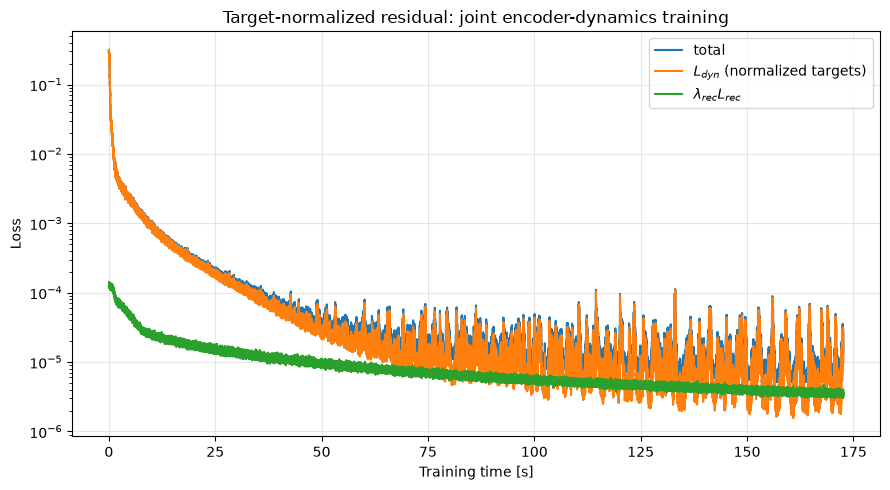

In [1009]:
target_normalized_training_time_axis = jnp.linspace(
    0.0, target_normalized_training_duration, num_training_steps
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 0],
    label="total",
)
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 1],
    label=r"$L_{dyn}$ (normalized targets)",
)
ax.plot(
    target_normalized_training_time_axis,
    lambda_rec * target_normalized_training_losses[:, 2],
    label=r"$\lambda_{rec} L_{rec}$",
)
ax.set_yscale("log")
ax.set_xlabel("Training time [s]")
ax.set_ylabel("Loss")
ax.set_title("Target-normalized residual: joint encoder-dynamics training")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()



## 10. Collect Fresh Validation Rollouts

In [1010]:
# This is a genuinely fresh evaluation dataset. Nothing in this cell updates
# the policy, encoder, decoder, or residual-dynamics parameters.
num_one_step_rollouts = 32
open_loop_validation_time = 5.0
one_step_num_steps = context_length + int(round(
    open_loop_validation_time / sim_dt
))
one_step_eval_env = HoveringStateEnv(
    max_steps_in_episode=one_step_num_steps,
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,
)
one_step_eval_env = MinMaxObservationWrapper(one_step_eval_env)
key_one_step_rollouts = experiment_key(6)
one_step_rollout_keys = jax.random.split(
    key_one_step_rollouts, num_one_step_rollouts
)
one_step_trajectories = parallel_rollout(
    one_step_eval_env,
    one_step_rollout_keys,
    policy_trained,
    dummy_residual_params,
)

one_step_env_states = one_step_trajectories.state
one_step_quad_states = one_step_env_states.quadrotor_state
one_step_states = state_vectors(
    one_step_quad_states.p[:, :-1],
    one_step_quad_states.R[:, :-1],
    one_step_quad_states.v[:, :-1],
)
one_step_actions = one_step_env_states.last_actions[:, 1:, -1, :]
one_step_state_actions = jnp.concatenate(
    [one_step_states, one_step_actions], axis=-1
)
one_step_normalized_state_actions = (
    one_step_state_actions - input_mean
) / input_std

one_step_done = jnp.logical_or(
    one_step_trajectories.terminated[:, 1:],
    one_step_trajectories.truncated[:, 1:],
)
one_step_valid_transition = (
    jnp.cumsum(one_step_done, axis=1) - one_step_done
) == 0
num_one_step_contexts = (
    one_step_state_actions.shape[1] - context_length
)
one_step_context_indices = (
    jnp.arange(num_one_step_contexts)[:, None]
    + jnp.arange(context_length)[None, :]
)
one_step_target_indices = (
    jnp.arange(num_one_step_contexts) + context_length
)
one_step_valid_context = (
    one_step_valid_transition[:, one_step_context_indices].all(axis=-1)
    & one_step_valid_transition[:, one_step_target_indices]
)

one_step_contexts = one_step_normalized_state_actions[
    :, one_step_context_indices
][one_step_valid_context]
one_step_inputs = one_step_normalized_state_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_current_states = one_step_states[
    :, one_step_target_indices
][one_step_valid_context]
one_step_target_actions = one_step_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_hidden_accelerations = one_step_env_states.hidden_acceleration[
    :, one_step_target_indices
][one_step_valid_context]
assert jnp.all(
    one_step_env_states.hidden_acceleration
    == one_step_env_states.hidden_acceleration[:, :1, :]
)

# Run the analytical prior once from each measured pre-transition state.
one_step_prior_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices][one_step_valid_context],
    one_step_env_states,
)
one_step_observed_next_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices + 1][one_step_valid_context],
    one_step_quad_states,
)
key_one_step_prior = experiment_key(7)
one_step_prior_keys = jax.random.split(
    key_one_step_prior, one_step_inputs.shape[0]
)
one_step_prior_next_states = evaluate_prior(
    one_step_prior_states,
    one_step_target_actions,
    one_step_prior_keys,
)
one_step_targets = state_difference(
    one_step_observed_next_states, one_step_prior_next_states
)
one_step_next_states = state_vectors(
    one_step_observed_next_states.p,
    one_step_observed_next_states.R,
    one_step_observed_next_states.v,
)

# Labels shared by one-step and open-loop validation.
head_slices = [slice(0, 3), slice(3, 6)]
head_labels = ["position", "velocity"]
head_units = ["m", "m/s"]
held_out_rollouts_to_plot = jnp.unique(validation_rollout_ids)[:4]

# Nominal errors are the baseline for the normalized model's learned correction.
nominal_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.p - one_step_observed_next_states.p
)))
nominal_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.v - one_step_observed_next_states.v
)))
print(f"Fresh one-step samples: {one_step_inputs.shape[0]:,}")


Fresh one-step samples: 8,000


## 11. Evaluate Target-Normalized One-Step Predictions

Held-out physical residual errors (target-normalized training):
   delta_p_x: MAE=1.607874e-05, RMSE=2.156641e-05
   delta_p_y: MAE=1.862092e-05, RMSE=2.342713e-05
   delta_p_z: MAE=6.923241e-12, RMSE=1.082601e-11
   delta_v_x: MAE=1.610013e-03, RMSE=2.159648e-03
   delta_v_y: MAE=1.863282e-03, RMSE=2.344112e-03
   delta_v_z: MAE=6.396938e-12, RMSE=9.861007e-12

Fresh one-step errors (target-normalized training):
Normalized-target L_dyn: 8.387776e-03
   delta_p_x: MAE=1.846997e-05, RMSE=3.367219e-05
   delta_p_y: MAE=2.222385e-05, RMSE=3.420267e-05
   delta_p_z: MAE=1.202913e-11, RMSE=1.737692e-11
   delta_v_x: MAE=1.845519e-03, RMSE=3.369802e-03
   delta_v_y: MAE=2.225128e-03, RMSE=3.425301e-03
   delta_v_z: MAE=7.560927e-12, RMSE=1.231357e-11
Physical one-step RMSE before -> after target-normalized correction:
  position: 1.744063e-04 -> 2.771051e-05 m
  velocity: 1.744037e-02 -> 2.774182e-03 m/s


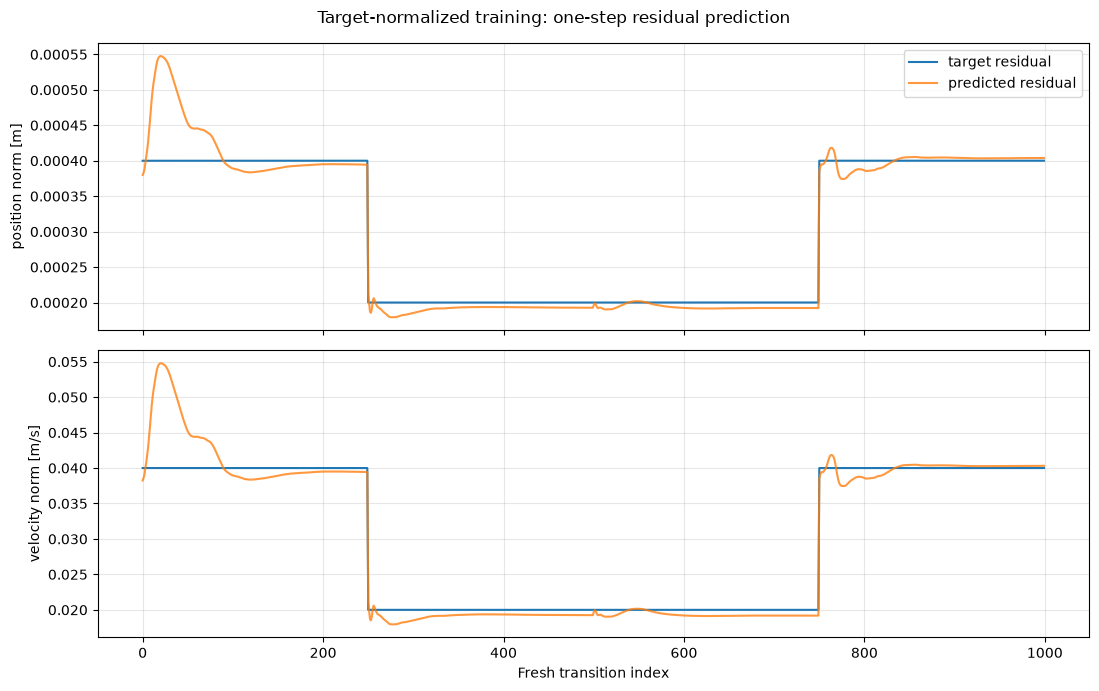

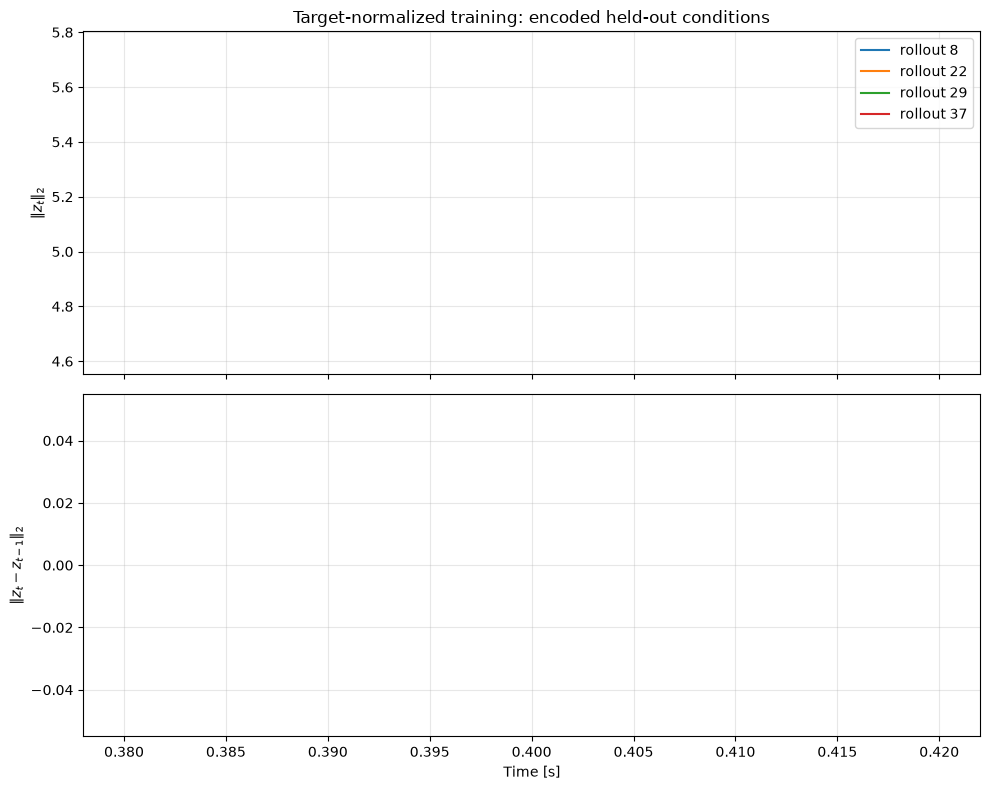

In [1013]:
# Held-out contexts from the original rollout-wise split. Convert model outputs
# back to physical residual units before reporting errors.
(
    target_normalized_validation_latents,
    target_normalized_validation_predictions_norm,
    _,
) = joint_forward(
    target_normalized_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
)
target_normalized_validation_predictions = (
    target_normalized_validation_predictions_norm * residual_target_std
    + residual_target_mean
)
target_normalized_validation_predictions.block_until_ready()
target_normalized_validation_errors = (
    target_normalized_validation_predictions - validation_targets
)
target_normalized_component_mae = jnp.abs(
    target_normalized_validation_errors
).mean(axis=(0, 1))
target_normalized_component_rmse = jnp.sqrt(jnp.square(
    target_normalized_validation_errors
).mean(axis=(0, 1)))

print("Held-out physical residual errors (target-normalized training):")
for name, mae, rmse in zip(
    component_names,
    target_normalized_component_mae,
    target_normalized_component_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")

# Evaluate the fresh one-step dataset collected in the preceding section.
target_normalized_one_step_latents = trajectory_encoder.apply(
    target_normalized_train_state.params["encoder"], one_step_contexts
)
target_normalized_one_step_predictions_norm = residual_model.apply(
    target_normalized_train_state.params["residual"],
    one_step_inputs,
    target_normalized_one_step_latents,
)
target_normalized_one_step_predictions = (
    target_normalized_one_step_predictions_norm * residual_target_std
    + residual_target_mean
)
one_step_dataset = {
    "context": one_step_contexts,
    "state": one_step_current_states,
    "action": one_step_target_actions,
    "next_state": one_step_next_states,
    "normalized_state_action": one_step_inputs,
    "target_residual": one_step_targets,
    "predicted_residual": target_normalized_one_step_predictions,
    "encoded_latent": target_normalized_one_step_latents,
    "hidden_acceleration_diagnostic": one_step_hidden_accelerations,
}
target_normalized_one_step_errors = (
    target_normalized_one_step_predictions - one_step_targets
)
target_normalized_one_step_mae = jnp.abs(
    target_normalized_one_step_errors
).mean(axis=0)
target_normalized_one_step_rmse = jnp.sqrt(jnp.square(
    target_normalized_one_step_errors
).mean(axis=0))
target_normalized_one_step_huber = optax.huber_loss(
    target_normalized_one_step_predictions_norm,
    (one_step_targets - residual_target_mean) / residual_target_std,
    delta=huber_delta,
).mean()

target_normalized_corrected_positions = (
    one_step_prior_next_states.p
    + target_normalized_one_step_predictions[:, :3]
)
target_normalized_corrected_velocities = (
    one_step_prior_next_states.v
    + target_normalized_one_step_predictions[:, 3:6]
)
target_normalized_corrected_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_positions - one_step_observed_next_states.p
)))
target_normalized_corrected_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_velocities - one_step_observed_next_states.v
)))

print("\nFresh one-step errors (target-normalized training):")
print(f"Normalized-target L_dyn: {target_normalized_one_step_huber:.6e}")
for name, mae, rmse in zip(
    component_names,
    target_normalized_one_step_mae,
    target_normalized_one_step_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")
print("Physical one-step RMSE before -> after target-normalized correction:")
print(
    f"  position: {nominal_position_rmse:.6e} -> "
    f"{target_normalized_corrected_position_rmse:.6e} m"
)
print(
    f"  velocity: {nominal_velocity_rmse:.6e} -> "
    f"{target_normalized_corrected_velocity_rmse:.6e} m/s"
)

num_target_normalized_plot_samples = min(
    1000, one_step_inputs.shape[0]
)
target_normalized_plot_indices = jnp.arange(
    num_target_normalized_plot_samples
)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, head_slice, head_label, head_unit in zip(
    axes, head_slices, head_labels, head_units
):
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            one_step_targets[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="target residual",
    )
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            target_normalized_one_step_predictions[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="predicted residual",
        alpha=0.8,
    )
    ax.set_ylabel(f"{head_label} norm [{head_unit}]")
    ax.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Fresh transition index")
fig.suptitle(
    "Target-normalized training: one-step residual prediction"
)
fig.tight_layout()
plt.show()

# Show how the newly trained encoder varies across held-out real contexts.
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for rollout_id in held_out_rollouts_to_plot:
    rollout_mask = validation_rollout_ids == rollout_id
    rollout_time = validation_context_times[rollout_mask] * sim_dt
    rollout_latents = target_normalized_validation_latents[rollout_mask]
    axes[0].plot(
        rollout_time,
        jnp.linalg.norm(rollout_latents, axis=-1),
        label=f"rollout {int(rollout_id)}",
    )
    axes[1].plot(
        rollout_time[1:],
        jnp.linalg.norm(
            rollout_latents[1:] - rollout_latents[:-1], axis=-1
        ),
    )
axes[0].set_ylabel(r"$\|z_t\|_2$")
axes[0].set_title(
    "Target-normalized training: encoded held-out conditions"
)
axes[0].legend()
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel(r"$\|z_t-z_{t-1}\|_2$")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


In [1012]:
# One-step latent-dependence diagnostic. This uses the trained validation
# tensors directly and is separate from recursive open-loop evaluation.
latent_ablation_all_latents = target_normalized_validation_latents
latent_ablation_validation_winds = np.asarray(jax.device_get(
    env_states.hidden_acceleration[validation_rollout_ids, 0, :]
))
latent_ablation_validation_rollout_ids = np.asarray(jax.device_get(
    validation_rollout_ids
))
unique_latent_ablation_winds, latent_ablation_condition_ids = np.unique(
    latent_ablation_validation_winds, axis=0, return_inverse=True
)
assert unique_latent_ablation_winds.shape[0] > 1, (
    "Wrong-wind evaluation requires at least two validation wind conditions"
)

# Map every condition to the next represented condition and take an actual
# validation-context latent from that condition. This cannot select the same
# wind accidentally, unlike an unchecked random permutation.
latent_ablation_representative_indices = np.asarray([
    np.flatnonzero(latent_ablation_condition_ids == condition_id)[0]
    for condition_id in range(unique_latent_ablation_winds.shape[0])
])
latent_ablation_wrong_condition_ids = (
    latent_ablation_condition_ids + 1
) % unique_latent_ablation_winds.shape[0]
latent_ablation_wrong_indices = latent_ablation_representative_indices[
    latent_ablation_wrong_condition_ids
]

# Build two distinct controls: another context from the same rollout, and a
# context from another rollout with the same wind. All four cases below are
# evaluated only where both replacements exist.
latent_ablation_same_rollout_indices = []
latent_ablation_same_wind_other_rollout_indices = []
all_latent_ablation_indices = np.arange(
    latent_ablation_all_latents.shape[0]
)
for context_index, (condition_id, rollout_id) in enumerate(zip(
    latent_ablation_condition_ids,
    latent_ablation_validation_rollout_ids,
)):
    same_condition = latent_ablation_condition_ids == condition_id
    same_rollout_candidates = np.flatnonzero(
        (latent_ablation_validation_rollout_ids == rollout_id)
        & (all_latent_ablation_indices != context_index)
    )
    other_rollout_candidates = np.flatnonzero(
        same_condition
        & (latent_ablation_validation_rollout_ids != rollout_id)
    )
    latent_ablation_same_rollout_indices.append(
        same_rollout_candidates[0] if same_rollout_candidates.size else -1
    )
    latent_ablation_same_wind_other_rollout_indices.append(
        other_rollout_candidates[0] if other_rollout_candidates.size else -1
    )
latent_ablation_same_rollout_indices = np.asarray(
    latent_ablation_same_rollout_indices, dtype=np.int32
)
latent_ablation_same_wind_other_rollout_indices = np.asarray(
    latent_ablation_same_wind_other_rollout_indices, dtype=np.int32
)
latent_ablation_eligible = (
    (latent_ablation_same_rollout_indices >= 0)
    & (latent_ablation_same_wind_other_rollout_indices >= 0)
)
latent_ablation_comparison_indices = np.flatnonzero(latent_ablation_eligible)
assert latent_ablation_comparison_indices.size > 0, (
    "No validation context supports all four latent comparisons"
)
latent_ablation_normal_latents = latent_ablation_all_latents[
    latent_ablation_comparison_indices
]
latent_ablation_same_rollout_latents = latent_ablation_all_latents[
    latent_ablation_same_rollout_indices[latent_ablation_comparison_indices]
]
latent_ablation_same_wind_other_rollout_latents = latent_ablation_all_latents[
    latent_ablation_same_wind_other_rollout_indices[latent_ablation_comparison_indices]
]
latent_ablation_wrong_latents = latent_ablation_all_latents[
    latent_ablation_wrong_indices[latent_ablation_comparison_indices]
]
latent_ablation_inputs = validation_dynamics_inputs[
    latent_ablation_comparison_indices
]
latent_ablation_normalized_targets = normalized_validation_targets[
    latent_ablation_comparison_indices
]
latent_ablation_physical_targets = validation_targets[
    latent_ablation_comparison_indices
]
assert np.all(np.any(
    latent_ablation_validation_winds[latent_ablation_comparison_indices]
    != latent_ablation_validation_winds[
        latent_ablation_wrong_indices[latent_ablation_comparison_indices]
    ],
    axis=-1,
)), "At least one replacement latent came from the same wind condition"
assert np.all(np.all(np.isclose(
    latent_ablation_validation_winds[latent_ablation_comparison_indices],
    latent_ablation_validation_winds[
        latent_ablation_same_wind_other_rollout_indices[latent_ablation_comparison_indices]
    ],
), axis=-1)), "A same-wind/other-rollout replacement has a different wind"
assert np.all(
    latent_ablation_validation_rollout_ids[latent_ablation_comparison_indices]
    == latent_ablation_validation_rollout_ids[
        latent_ablation_same_rollout_indices[latent_ablation_comparison_indices]
    ]
), "A same-rollout replacement came from another rollout"
assert np.all(
    latent_ablation_validation_rollout_ids[latent_ablation_comparison_indices]
    != latent_ablation_validation_rollout_ids[
        latent_ablation_same_wind_other_rollout_indices[latent_ablation_comparison_indices]
    ]
), "A same-wind/other-rollout replacement reused the same rollout"

def latent_ablation_predictions(normalized_latents):
    expanded_latents = jnp.broadcast_to(
        normalized_latents[:, None, :],
        latent_ablation_inputs.shape[:-1] + (latent_dim,),
    )
    return residual_model.apply(
        target_normalized_train_state.params["residual"],
        latent_ablation_inputs,
        expanded_latents,
    )

latent_ablation_normal_predictions_norm = latent_ablation_predictions(
    latent_ablation_normal_latents
)
latent_ablation_same_rollout_predictions_norm = latent_ablation_predictions(
    latent_ablation_same_rollout_latents
)
latent_ablation_same_wind_other_rollout_predictions_norm = latent_ablation_predictions(
    latent_ablation_same_wind_other_rollout_latents
)
latent_ablation_wrong_predictions_norm = latent_ablation_predictions(
    latent_ablation_wrong_latents
)
assert jnp.allclose(
    latent_ablation_normal_predictions_norm,
    target_normalized_validation_predictions_norm[latent_ablation_comparison_indices],
    atol=1e-6,
), "Normal-latent predictions differ from the existing validation path"

def latent_ablation_dynamics_loss(normalized_predictions):
    return optax.huber_loss(
        normalized_predictions,
        latent_ablation_normalized_targets,
        delta=huber_delta,
    ).mean()

latent_ablation_normal_loss = latent_ablation_dynamics_loss(
    latent_ablation_normal_predictions_norm
)
latent_ablation_same_rollout_loss = latent_ablation_dynamics_loss(
    latent_ablation_same_rollout_predictions_norm
)
latent_ablation_same_wind_other_rollout_loss = latent_ablation_dynamics_loss(
    latent_ablation_same_wind_other_rollout_predictions_norm
)
latent_ablation_wrong_loss = latent_ablation_dynamics_loss(
    latent_ablation_wrong_predictions_norm
)
latent_ablation_wrong_ratio = (
    latent_ablation_wrong_loss
    / jnp.maximum(latent_ablation_normal_loss, 1e-12)
)
latent_ablation_same_rollout_ratio = (
    latent_ablation_same_rollout_loss
    / jnp.maximum(latent_ablation_normal_loss, 1e-12)
)
latent_ablation_same_wind_other_rollout_ratio = (
    latent_ablation_same_wind_other_rollout_loss
    / jnp.maximum(latent_ablation_normal_loss, 1e-12)
)

def latent_ablation_physical_rmse(normalized_predictions):
    physical_predictions = (
        normalized_predictions * residual_target_std
        + residual_target_mean
    )
    return jnp.sqrt(jnp.mean(jnp.square(
        physical_predictions - latent_ablation_physical_targets
    ), axis=(0, 1)))

latent_ablation_normal_rmse = latent_ablation_physical_rmse(
    latent_ablation_normal_predictions_norm
)
latent_ablation_same_rollout_rmse = latent_ablation_physical_rmse(
    latent_ablation_same_rollout_predictions_norm
)
latent_ablation_same_wind_other_rollout_rmse = latent_ablation_physical_rmse(
    latent_ablation_same_wind_other_rollout_predictions_norm
)
latent_ablation_wrong_rmse = latent_ablation_physical_rmse(
    latent_ablation_wrong_predictions_norm
)
latent_ablation_wrong_rmse.block_until_ready()

print("One-step residual-model latent-dependence diagnostic:")
print(f"  represented validation winds: {unique_latent_ablation_winds.shape[0]}")
print(
    "  contexts eligible for all four cases: "
    f"{latent_ablation_comparison_indices.size}/"
    f"{latent_ablation_all_latents.shape[0]}"
)
print(f"  Own latent L_dyn:                         {latent_ablation_normal_loss:.6e}")
print(f"  Different context, same rollout L_dyn:   {latent_ablation_same_rollout_loss:.6e}")
print(f"  Different rollout, same wind L_dyn:      {latent_ablation_same_wind_other_rollout_loss:.6e}")
print(f"  Different-wind latent L_dyn:              {latent_ablation_wrong_loss:.6e}")
print(f"  Same-rollout / own ratio:                 {latent_ablation_same_rollout_ratio:.3f}")
print(f"  Same-wind-other-rollout / own ratio:      {latent_ablation_same_wind_other_rollout_ratio:.3f}")
print(f"  Different-wind / own ratio:               {latent_ablation_wrong_ratio:.3f}")
print("\nPhysical residual RMSE per component:")
print("  component          own       same-rollout   same-wind/other-rollout   wrong-wind")
for component_name, normal_rmse, same_rollout_rmse, same_wind_other_rollout_rmse, wrong_rmse in zip(
    component_names,
    latent_ablation_normal_rmse,
    latent_ablation_same_rollout_rmse,
    latent_ablation_same_wind_other_rollout_rmse,
    latent_ablation_wrong_rmse,
):
    print(
        f"  {component_name:>10s}  {normal_rmse:.6e}  "
        f"{same_rollout_rmse:.6e}  "
        f"{same_wind_other_rollout_rmse:.6e}  {wrong_rmse:.6e}"
    )


AssertionError: No validation context supports all four latent comparisons

In [ ]:
# Evaluation only: test sensitivity to temporal distance between contexts
# within the same validation rollout. No parameters are updated here.
temporal_latent_offsets = (0, 1, 2, 3, 5, 10)
temporal_rollout_ids = np.asarray(jax.device_get(validation_rollout_ids))
temporal_context_times = np.asarray(jax.device_get(validation_context_times))
temporal_all_latents = target_normalized_validation_latents
temporal_offset_results = {}

for context_offset in temporal_latent_offsets:
    reference_indices = []
    replacement_indices = []
    for rollout_id in np.unique(temporal_rollout_ids):
        rollout_indices = np.flatnonzero(temporal_rollout_ids == rollout_id)
        rollout_indices = rollout_indices[
            np.argsort(temporal_context_times[rollout_indices])
        ]
        if context_offset == 0:
            reference_indices.extend(rollout_indices.tolist())
            replacement_indices.extend(rollout_indices.tolist())
            continue
        for signed_offset in (-context_offset, context_offset):
            if signed_offset < 0:
                reference_positions = np.arange(-signed_offset, rollout_indices.size)
            else:
                reference_positions = np.arange(0, rollout_indices.size - signed_offset)
            replacement_positions = reference_positions + signed_offset
            reference_indices.extend(rollout_indices[reference_positions].tolist())
            replacement_indices.extend(rollout_indices[replacement_positions].tolist())

    reference_indices = np.asarray(reference_indices, dtype=np.int32)
    replacement_indices = np.asarray(replacement_indices, dtype=np.int32)
    assert reference_indices.size == replacement_indices.size
    assert reference_indices.size > 0, (
        f"No within-rollout context pairs exist at offset {context_offset}"
    )
    assert np.all(
        temporal_rollout_ids[reference_indices]
        == temporal_rollout_ids[replacement_indices]
    ), "A temporal replacement crossed a rollout boundary"

    offset_inputs = validation_dynamics_inputs[reference_indices]
    offset_targets_norm = normalized_validation_targets[reference_indices]
    offset_targets_physical = validation_targets[reference_indices]
    offset_latents = temporal_all_latents[replacement_indices]
    offset_latents = jnp.broadcast_to(
        offset_latents[:, None, :],
        offset_inputs.shape[:-1] + (latent_dim,),
    )
    offset_predictions_norm = residual_model.apply(
        target_normalized_train_state.params["residual"],
        offset_inputs,
        offset_latents,
    )
    offset_loss = optax.huber_loss(
        offset_predictions_norm,
        offset_targets_norm,
        delta=huber_delta,
    ).mean()
    offset_predictions_physical = (
        offset_predictions_norm * residual_target_std
        + residual_target_mean
    )
    offset_physical_rmse = jnp.sqrt(jnp.mean(jnp.square(
        offset_predictions_physical - offset_targets_physical
    ), axis=(0, 1)))
    offset_physical_rmse.block_until_ready()
    temporal_offset_results[context_offset] = {
        "num_pairs": reference_indices.size,
        "loss": offset_loss,
        "physical_rmse": offset_physical_rmse,
    }

temporal_offset_zero_loss = temporal_offset_results[0]["loss"]
print("Within-rollout temporal latent-offset diagnostic:")
print("  offset   valid pairs          L_dyn    ratio / offset 0")
for context_offset in temporal_latent_offsets:
    result = temporal_offset_results[context_offset]
    loss_ratio = result["loss"] / jnp.maximum(
        temporal_offset_zero_loss, 1e-12
    )
    print(
        f"  {context_offset:>6d}   {result['num_pairs']:>11d}   "
        f"{result['loss']:.6e}   {loss_ratio:.3f}"
    )

print("\nPhysical residual RMSE per component:")
print("  offset  " + "  ".join(f"{name:>10s}" for name in component_names))
for context_offset in temporal_latent_offsets:
    rmse = temporal_offset_results[context_offset]["physical_rmse"]
    print(
        f"  {context_offset:>6d}  "
        + "  ".join(f"{value:.6e}" for value in rmse)
    )


AssertionError: No within-rollout context pairs exist at offset 2

In [ ]:
# Matched-sample temporal latent-offset diagnostic. For every offset, the
# own- and substituted-latent cases use identical target transitions.
matched_temporal_offsets = (1, 2, 3, 5, 10)
matched_temporal_rollout_ids = np.asarray(jax.device_get(validation_rollout_ids))
matched_temporal_context_times = np.asarray(jax.device_get(validation_context_times))
matched_temporal_results = {}

for context_offset in matched_temporal_offsets:
    reference_indices = []
    replacement_indices = []
    for rollout_id in np.unique(matched_temporal_rollout_ids):
        rollout_indices = np.flatnonzero(
            matched_temporal_rollout_ids == rollout_id
        )
        rollout_indices = rollout_indices[
            np.argsort(matched_temporal_context_times[rollout_indices])
        ]
        for signed_offset in (-context_offset, context_offset):
            if signed_offset < 0:
                reference_positions = np.arange(
                    -signed_offset, rollout_indices.size
                )
            else:
                reference_positions = np.arange(
                    0, rollout_indices.size - signed_offset
                )
            replacement_positions = reference_positions + signed_offset
            reference_indices.extend(
                rollout_indices[reference_positions].tolist()
            )
            replacement_indices.extend(
                rollout_indices[replacement_positions].tolist()
            )

    reference_indices = np.asarray(reference_indices, dtype=np.int32)
    replacement_indices = np.asarray(replacement_indices, dtype=np.int32)
    assert reference_indices.size == replacement_indices.size
    assert reference_indices.size > 0, (
        f"No matched context pairs exist at offset {context_offset}"
    )
    assert np.all(
        matched_temporal_rollout_ids[reference_indices]
        == matched_temporal_rollout_ids[replacement_indices]
    ), "A matched temporal pair crossed a rollout boundary"

    matched_inputs = validation_dynamics_inputs[reference_indices]
    matched_targets_norm = normalized_validation_targets[reference_indices]
    matched_targets_physical = validation_targets[reference_indices]
    own_latents = target_normalized_validation_latents[reference_indices]
    substituted_latents = target_normalized_validation_latents[
        replacement_indices
    ]
    own_latents = jnp.broadcast_to(
        own_latents[:, None, :],
        matched_inputs.shape[:-1] + (latent_dim,),
    )
    substituted_latents = jnp.broadcast_to(
        substituted_latents[:, None, :],
        matched_inputs.shape[:-1] + (latent_dim,),
    )

    own_predictions_norm = residual_model.apply(
        target_normalized_train_state.params["residual"],
        matched_inputs,
        own_latents,
    )
    substituted_predictions_norm = residual_model.apply(
        target_normalized_train_state.params["residual"],
        matched_inputs,
        substituted_latents,
    )
    own_loss = optax.huber_loss(
        own_predictions_norm,
        matched_targets_norm,
        delta=huber_delta,
    ).mean()
    substituted_loss = optax.huber_loss(
        substituted_predictions_norm,
        matched_targets_norm,
        delta=huber_delta,
    ).mean()

    own_predictions_physical = (
        own_predictions_norm * residual_target_std + residual_target_mean
    )
    substituted_predictions_physical = (
        substituted_predictions_norm * residual_target_std
        + residual_target_mean
    )
    own_rmse = jnp.sqrt(jnp.mean(jnp.square(
        own_predictions_physical - matched_targets_physical
    ), axis=(0, 1)))
    substituted_rmse = jnp.sqrt(jnp.mean(jnp.square(
        substituted_predictions_physical - matched_targets_physical
    ), axis=(0, 1)))
    substituted_rmse.block_until_ready()
    matched_temporal_results[context_offset] = {
        "num_pairs": reference_indices.size,
        "own_loss": own_loss,
        "substituted_loss": substituted_loss,
        "own_rmse": own_rmse,
        "substituted_rmse": substituted_rmse,
    }

print("Matched within-rollout temporal latent-offset diagnostic:")
print("  offset   valid pairs      own L_dyn    substituted L_dyn     ratio")
for context_offset in matched_temporal_offsets:
    result = matched_temporal_results[context_offset]
    ratio = result["substituted_loss"] / jnp.maximum(
        result["own_loss"], 1e-12
    )
    print(
        f"  {context_offset:>6d}   {result['num_pairs']:>11d}   "
        f"{result['own_loss']:.6e}      "
        f"{result['substituted_loss']:.6e}   {ratio:.3f}"
    )

print("\nMatched physical residual RMSE per component:")
print("  offset   component          own    substituted")
for context_offset in matched_temporal_offsets:
    result = matched_temporal_results[context_offset]
    for component_name, own_value, substituted_value in zip(
        component_names, result["own_rmse"], result["substituted_rmse"]
    ):
        print(
            f"  {context_offset:>6d}   {component_name:>10s}   "
            f"{own_value:.6e}   {substituted_value:.6e}"
        )


AssertionError: No matched context pairs exist at offset 1

## 12. Prepare the Five-Second Open-Loop Evaluation

In [1014]:
# Match the paper's dynamics evaluation: infer one latent from the measured
# context, then hold it fixed while recursively replaying the same recorded
# action sequence from the same measured initial state.
open_loop_horizon = int(round(open_loop_validation_time / sim_dt))
assert context_length + open_loop_horizon <= one_step_state_actions.shape[1]

# Include every rollout with a valid encoder context and at least one valid
# post-context transition. Targets after termination remain masked.
open_loop_context_valid = one_step_valid_transition[
    :, :context_length
].all(axis=1)
open_loop_available_steps = one_step_valid_transition[
    :, context_length:context_length + open_loop_horizon
].sum(axis=1)
open_loop_eligible = (
    open_loop_context_valid & (open_loop_available_steps > 0)
)
assert bool(jnp.any(open_loop_eligible)), (
    "No fresh rollout is valid beyond the initial encoder context"
)
open_loop_rollout_indices = jnp.flatnonzero(open_loop_eligible)
open_loop_valid_mask = one_step_valid_transition[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]

open_loop_initial_states = jax.tree.map(
    lambda leaf: leaf[open_loop_rollout_indices, context_length],
    one_step_env_states,
)
open_loop_initial_contexts = one_step_normalized_state_actions[
    open_loop_rollout_indices, :context_length
]
open_loop_actions = one_step_actions[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
key_open_loop = experiment_key(8)
open_loop_keys = jax.random.split(
    key_open_loop,
    open_loop_rollout_indices.shape[0] * open_loop_horizon,
).reshape(open_loop_rollout_indices.shape[0], open_loop_horizon)

open_loop_true_states = jax.tree.map(
    lambda leaf: leaf[
        open_loop_rollout_indices,
        context_length + 1:context_length + open_loop_horizon + 1,
    ],
    one_step_quad_states,
)
open_loop_time = sim_dt * (jnp.arange(open_loop_horizon) + 1)
print(
    f"Open-loop evaluation rollouts: {open_loop_rollout_indices.shape[0]}"
)
print(
    f"Open-loop horizon: {open_loop_horizon} steps "
    f"({open_loop_time[-1]:.2f} s)"
)
print(
    f"Rollouts valid at {open_loop_validation_time:.1f} s: "
    f"{open_loop_valid_mask[:, -1].sum()}"
)


Open-loop evaluation rollouts: 32
Open-loop horizon: 250 steps (5.00 s)
Rollouts valid at 5.0 s: 32


## 13. Evaluate Target-Normalized Five-Second Open-Loop Predictions

Paper-style open-loop cumulative dynamics error:
  mean Euclidean position error: 6.269283e-01 +/- 3.384937e-01 m
  rollout 0: w=(-2.00, -0.00) m/s^2, error=4.329318e-01 m
  rollout 1: w=(-1.00, -0.00) m/s^2, error=3.772509e-01 m
  rollout 2: w=(-1.00, -0.00) m/s^2, error=3.745822e-01 m
  rollout 3: w=(+0.00, -2.00) m/s^2, error=4.342835e-01 m
  rollout 4: w=(+1.41, -1.41) m/s^2, error=1.706967e+00 m
  rollout 5: w=(+1.00, +0.00) m/s^2, error=9.432250e-01 m
  rollout 6: w=(+0.00, -1.00) m/s^2, error=8.071933e-01 m
  rollout 7: w=(-0.71, +0.71) m/s^2, error=7.322829e-01 m
  rollout 8: w=(-1.41, +1.41) m/s^2, error=7.747892e-01 m
  rollout 9: w=(+1.00, +0.00) m/s^2, error=8.393666e-02 m
  rollout 10: w=(+1.41, +1.41) m/s^2, error=8.525169e-01 m
  rollout 11: w=(-2.00, -0.00) m/s^2, error=7.725431e-01 m
  rollout 12: w=(-2.00, -0.00) m/s^2, error=1.102686e+00 m
  rollout 13: w=(+0.00, +0.00) m/s^2, error=4.720586e-01 m
  rollout 14: w=(-1.41, -1.41) m/s^2, error=3.127078e-01 m
  rollout 1

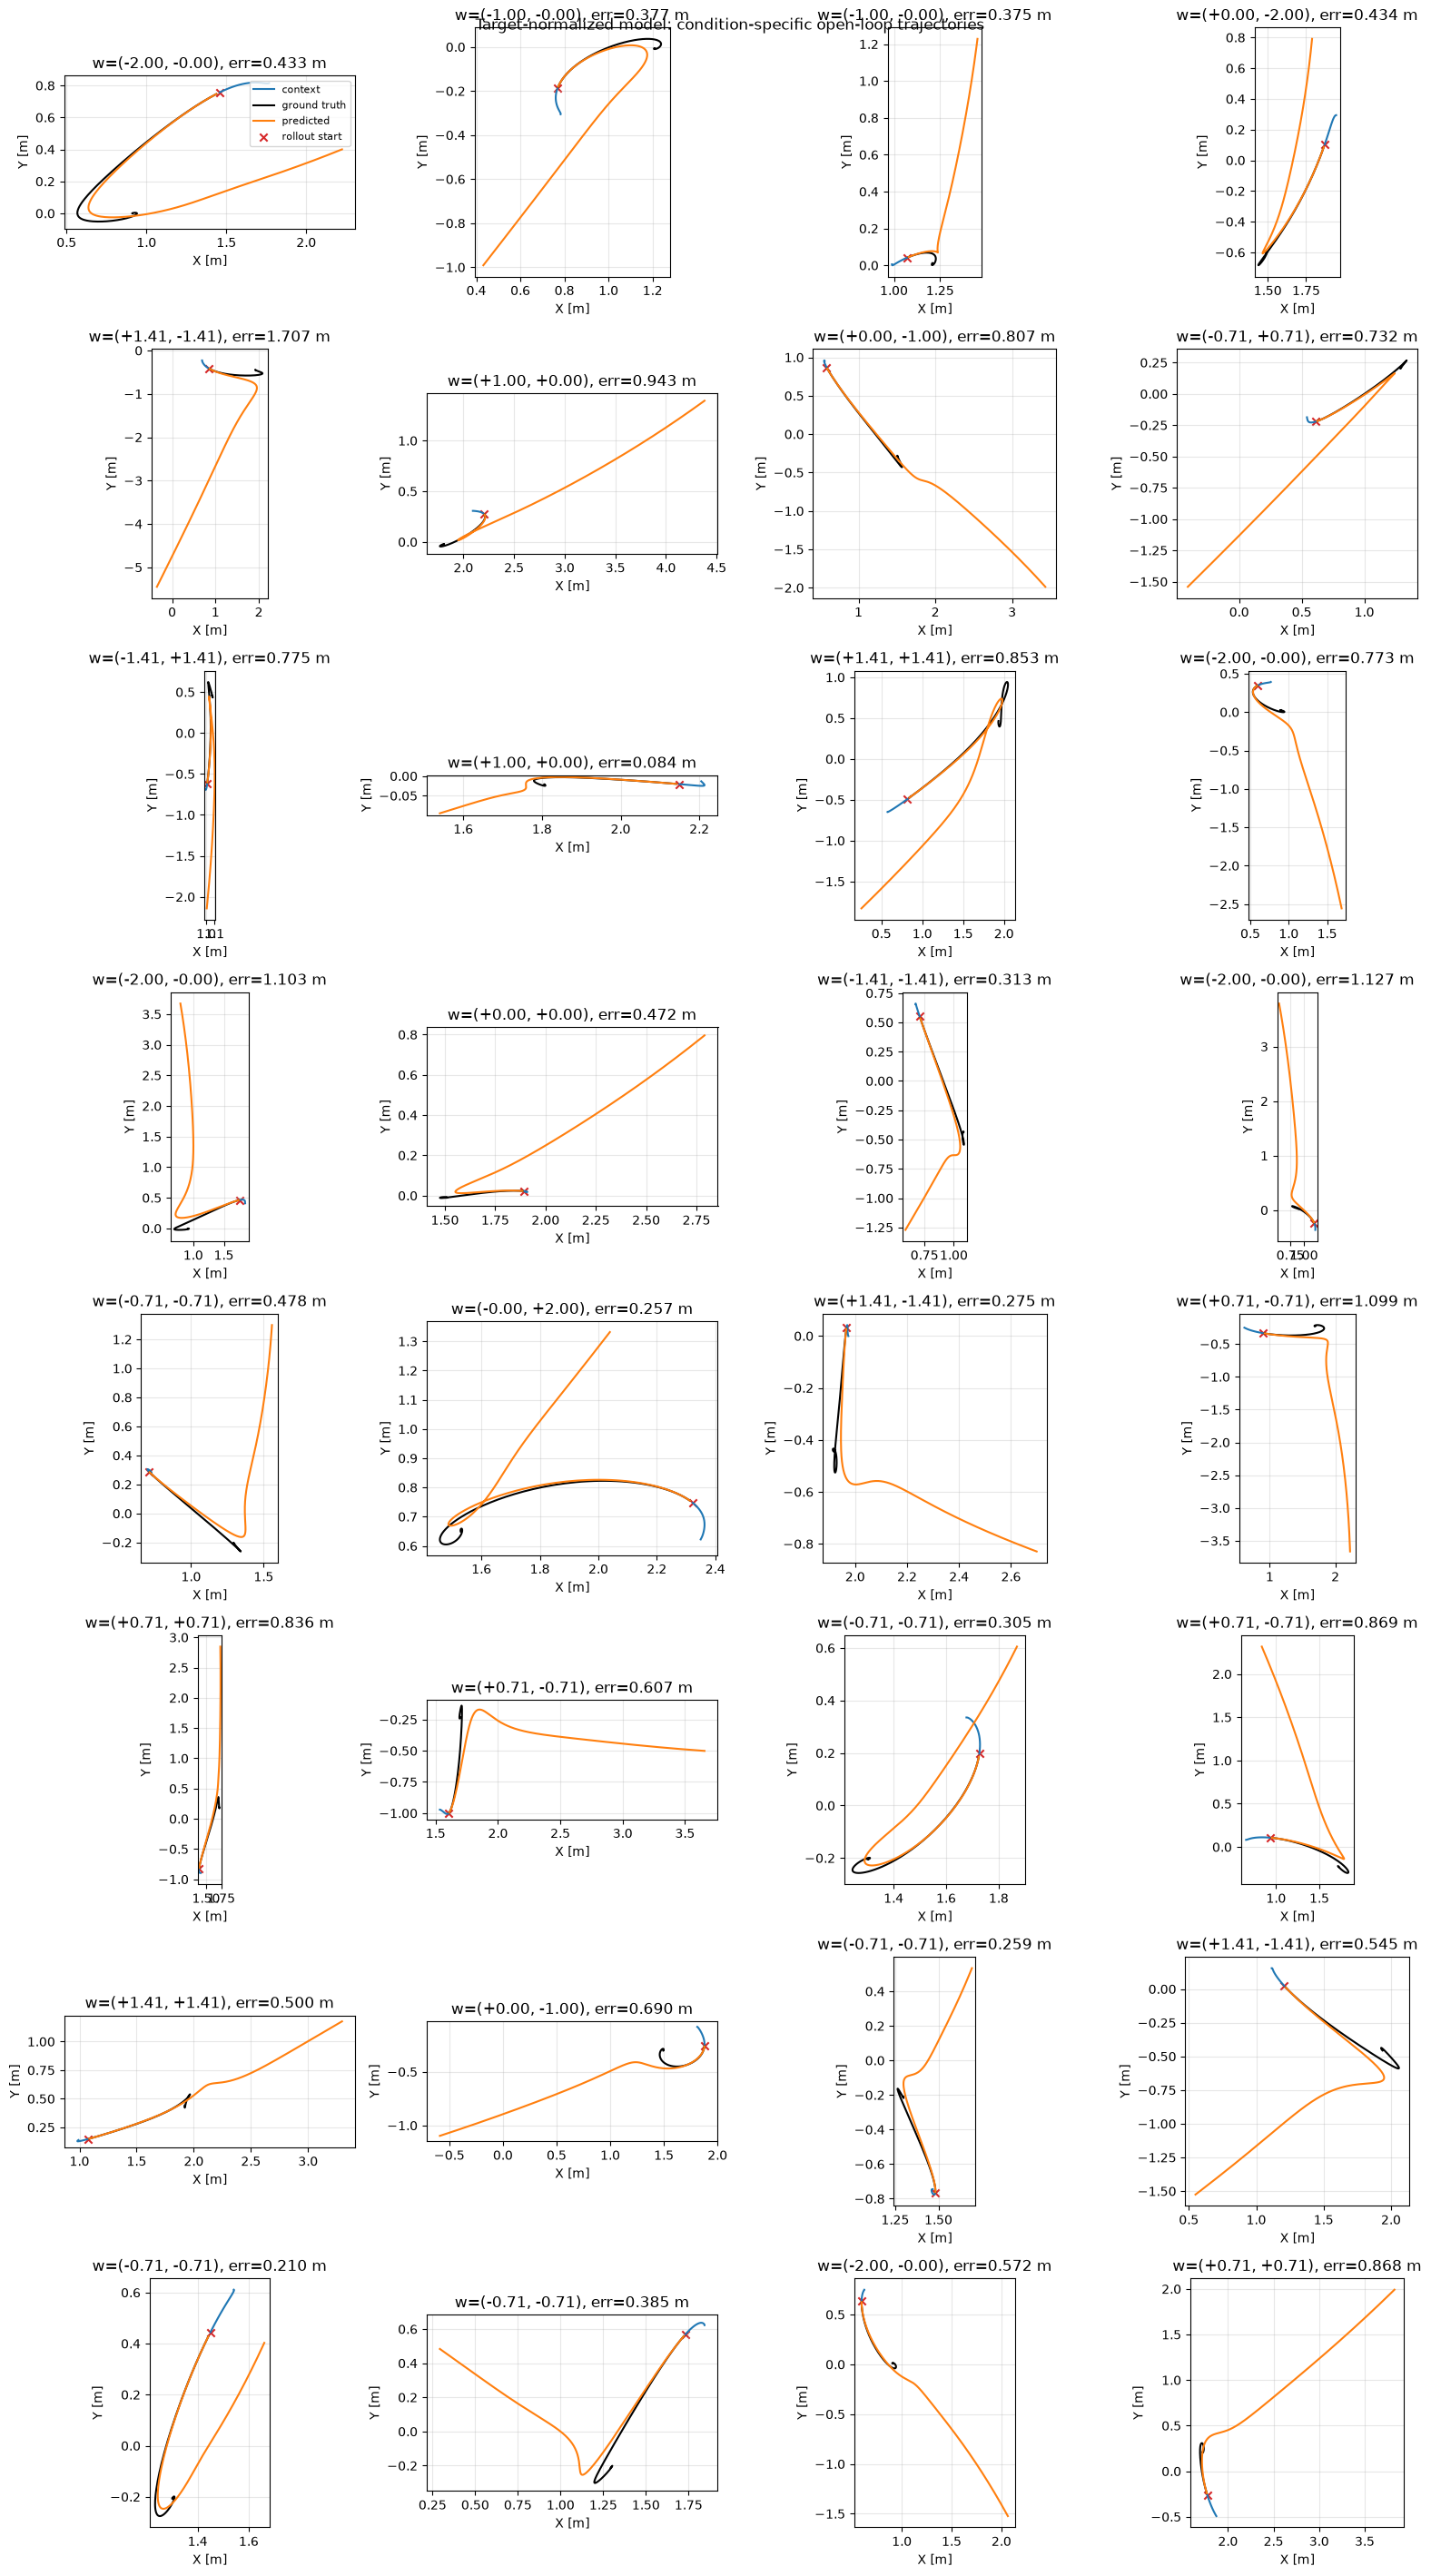

In [1017]:
# The paper-style protocol is unchanged: infer one latent from the measured
# context, hold it fixed, and replay the same actions recursively for 5 s.
def target_normalized_learned_open_loop(
    initial_state, initial_context, action_sequence, step_keys
):
    fixed_latent = trajectory_encoder.apply(
        target_normalized_train_state.params["encoder"], initial_context
    )

    def learned_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        current_state = state_vectors(
            predicted_state.quadrotor_state.p,
            predicted_state.quadrotor_state.R,
            predicted_state.quadrotor_state.v,
        )
        normalized_state_action = (
            jnp.concatenate([current_state, action], axis=-1) - input_mean
        ) / input_std
        prior_transition = prior_env._step(
            predicted_state, action, {}, step_key
        )
        prior_quad_state = prior_transition.state.quadrotor_state
        predicted_residual_norm = residual_model.apply(
            target_normalized_train_state.params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        predicted_residual = (
            predicted_residual_norm * residual_target_std
            + residual_target_mean
        )
        corrected_quad_state = prior_quad_state.replace(
            p=prior_quad_state.p + predicted_residual[:3],
            v=prior_quad_state.v + predicted_residual[3:6],
        )
        corrected_state = prior_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        return corrected_state, (corrected_quad_state, predicted_residual)

    _, outputs = jax.lax.scan(
        learned_step,
        initial_state,
        (action_sequence, step_keys),
    )
    predicted_states, predicted_residuals = outputs
    return predicted_states, predicted_residuals, fixed_latent

evaluate_target_normalized_open_loop = jax.jit(
    jax.vmap(target_normalized_learned_open_loop)
)
(
    target_normalized_open_loop_states,
    target_normalized_open_loop_residuals,
    target_normalized_open_loop_latents,
) = evaluate_target_normalized_open_loop(
    open_loop_initial_states,
    open_loop_initial_contexts,
    open_loop_actions,
    open_loop_keys,
)
target_normalized_open_loop_states.p.block_until_ready()

# Paper-style dynamics error: Euclidean position error at each open-loop
# timestep. Average over time within each rollout, then over rollouts so
# every trajectory receives equal weight regardless of valid duration.
open_loop_position_error = jnp.linalg.norm(
    target_normalized_open_loop_states.p - open_loop_true_states.p,
    axis=-1,
)
masked_open_loop_position_error = jnp.where(
    open_loop_valid_mask, open_loop_position_error, jnp.nan
)
per_rollout_cumulative_dynamics_error = (
    jnp.nansum(masked_open_loop_position_error, axis=1)
    / jnp.maximum(open_loop_valid_mask.sum(axis=1), 1)
)
cumulative_dynamics_error = jnp.mean(
    per_rollout_cumulative_dynamics_error
)
cumulative_dynamics_error_std = jnp.std(
    per_rollout_cumulative_dynamics_error
)
open_loop_winds = one_step_env_states.hidden_acceleration[
    open_loop_rollout_indices, 0, :
]
print("Paper-style open-loop cumulative dynamics error:")
print(
    f"  mean Euclidean position error: "
    f"{cumulative_dynamics_error:.6e} +/- "
    f"{cumulative_dynamics_error_std:.6e} m"
)
for rollout_index, (wind, rollout_error) in enumerate(zip(
    open_loop_winds, per_rollout_cumulative_dynamics_error
)):
    print(
        f"  rollout {rollout_index}: "
        f"w=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}) m/s^2, "
        f"error={float(rollout_error):.6e} m"
    )

# Match the paper's condition-specific XY visualization instead of
# averaging residual magnitudes across unrelated trajectories.
num_open_loop_plots = open_loop_rollout_indices.shape[0]
num_plot_columns = min(4, num_open_loop_plots)
num_plot_rows = (num_open_loop_plots + num_plot_columns - 1) // num_plot_columns
fig, axes = plt.subplots(
    num_plot_rows, num_plot_columns,
    figsize=(4.0 * num_plot_columns, 3.6 * num_plot_rows),
    squeeze=False,
)
flat_axes = axes.ravel()
for plot_index in range(num_open_loop_plots):
    ax = flat_axes[plot_index]
    rollout_id = open_loop_rollout_indices[plot_index]
    context_positions = one_step_quad_states.p[
        rollout_id, :context_length + 1
    ]
    true_positions = open_loop_true_states.p[plot_index]
    predicted_positions = target_normalized_open_loop_states.p[plot_index]
    valid_steps = open_loop_valid_mask[plot_index]
    wind = open_loop_winds[plot_index]
    ax.plot(
        context_positions[:, 0], context_positions[:, 1],
        label="context", color="C0",
    )
    ax.plot(
        jnp.where(valid_steps, true_positions[:, 0], jnp.nan),
        jnp.where(valid_steps, true_positions[:, 1], jnp.nan),
        label="ground truth", color="black",
    )
    ax.plot(
        jnp.where(valid_steps, predicted_positions[:, 0], jnp.nan),
        jnp.where(valid_steps, predicted_positions[:, 1], jnp.nan),
        label="predicted", color="C1",
    )
    ax.scatter(
        context_positions[-1, 0], context_positions[-1, 1],
        marker="x", color="C3", label="rollout start",
    )
    ax.set_title(
        f"w=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}), "
        f"err={float(per_rollout_cumulative_dynamics_error[plot_index]):.3f} m"
    )
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
for unused_axis in flat_axes[num_open_loop_plots:]:
    unused_axis.set_visible(False)
flat_axes[0].legend(fontsize=8)
fig.suptitle(
    "Target-normalized model: condition-specific open-loop trajectories"
)
fig.tight_layout()
plt.show()

# Visualize the encoder outputs actually used by every multi-step validation
# rollouts. This evaluator holds the initial-context latent fixed, so its
# norm is constant and the step-to-step latent change is identically zero.
num_multi_step_latent_plots = target_normalized_open_loop_latents.shape[0]
multi_step_validation_latents = jnp.broadcast_to(
    target_normalized_open_loop_latents[
        :num_multi_step_latent_plots, None, :
    ],
    (
        num_multi_step_latent_plots,
        open_loop_horizon,
        target_normalized_open_loop_latents.shape[-1],
    ),
)

# fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# for plot_index in range(num_multi_step_latent_plots):
#     rollout_id = int(open_loop_rollout_indices[plot_index])
#     rollout_latents = multi_step_validation_latents[plot_index]
#     axes[0].plot(
#         open_loop_time,
#         jnp.linalg.norm(rollout_latents, axis=-1),
#         label=f"rollout {rollout_id}",
#     )
#     axes[1].plot(
#         open_loop_time[1:],
#         jnp.linalg.norm(
#             rollout_latents[1:] - rollout_latents[:-1], axis=-1
#         ),
#     )
# axes[0].set_ylabel(r"$\|z_t\|_2$")
# axes[0].set_title(
#     "Target-normalized training: encoded multi-step validation conditions"
# )
# axes[0].legend()
# axes[1].set_xlabel("Open-loop time [s]")
# axes[1].set_ylabel(r"$\|z_t-z_{t-1}\|_2$")
# for ax in axes:
#     ax.grid(True, alpha=0.3)
# fig.tight_layout()
# plt.show()


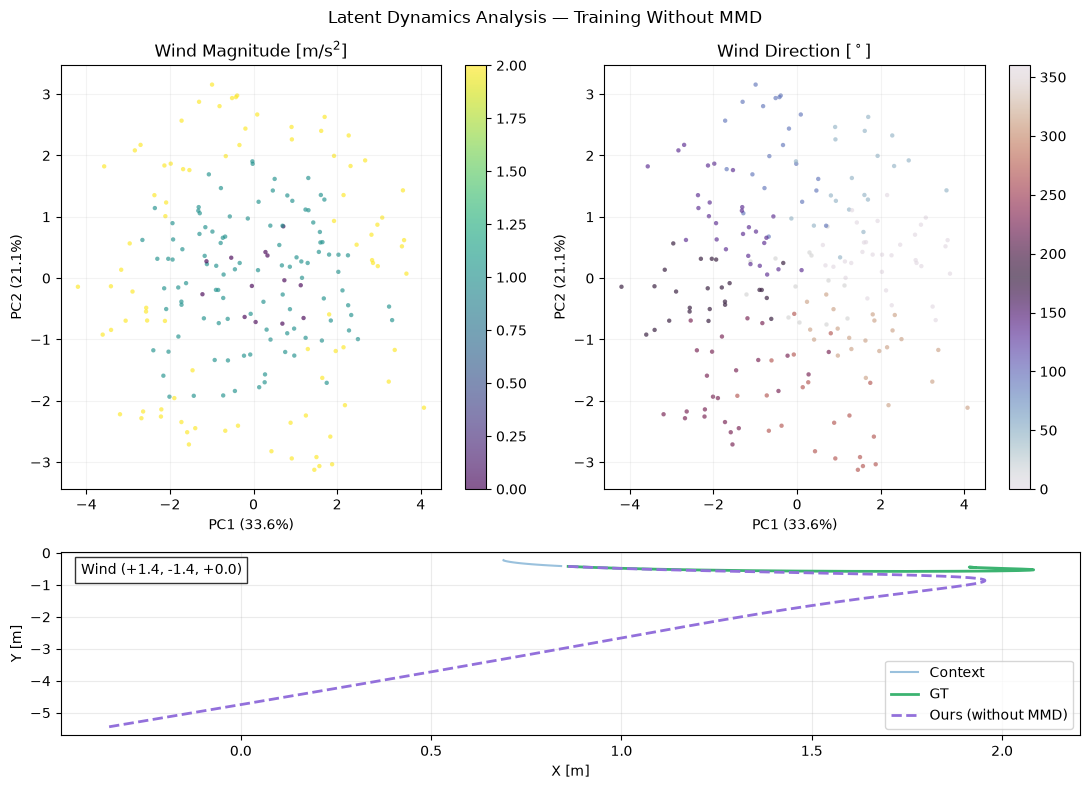

Without-MMD PCA variance explained by PC1 + PC2: 54.69%
Latent windows plotted: 205
Representative rollout: 4, wind=[ 1.414214  -1.4142131  0.       ]


In [1018]:
# Paper-style latent analysis for the target-normalized model trained without MMD.
# Wind labels are used only to color the final encoder outputs.
no_mmd_plot_latents = np.asarray(jax.device_get(
    target_normalized_validation_latents
))
no_mmd_plot_winds = np.asarray(jax.device_get(
    env_states.hidden_acceleration[validation_rollout_ids, 0, :]
))
assert no_mmd_plot_latents.shape == (
    no_mmd_plot_winds.shape[0], latent_dim
)

# Compute one centered PCA projection and reuse the same 2-D coordinates in
# the magnitude and direction panels.
no_mmd_latent_mean = no_mmd_plot_latents.mean(axis=0, keepdims=True)
no_mmd_centered_latents = no_mmd_plot_latents - no_mmd_latent_mean
_, no_mmd_singular_values, no_mmd_pca_directions = np.linalg.svd(
    no_mmd_centered_latents, full_matrices=False
)
no_mmd_latent_2d = no_mmd_centered_latents @ no_mmd_pca_directions[:2].T
no_mmd_pca_variance = no_mmd_singular_values**2
no_mmd_explained_variance = (
    no_mmd_pca_variance / max(no_mmd_pca_variance.sum(), 1e-12)
)
no_mmd_wind_magnitude = np.linalg.norm(no_mmd_plot_winds, axis=-1)
no_mmd_nonzero_wind = no_mmd_wind_magnitude > 1e-8
no_mmd_wind_direction = (
    np.degrees(np.arctan2(
        no_mmd_plot_winds[:, 1], no_mmd_plot_winds[:, 0]
    )) % 360.0
)

# Use the existing non-MMD open-loop prediction for the representative trace.
no_mmd_desired_wind = np.asarray([2.0, -2.0, 0.0])
no_mmd_available_winds = np.asarray(jax.device_get(open_loop_winds))
no_mmd_representative_index = int(np.argmin(np.linalg.norm(
    no_mmd_available_winds - no_mmd_desired_wind[None, :], axis=-1
)))
no_mmd_rollout_id = int(
    open_loop_rollout_indices[no_mmd_representative_index]
)
no_mmd_representative_valid = np.asarray(jax.device_get(
    open_loop_valid_mask[no_mmd_representative_index]
))
no_mmd_context_xy = np.asarray(jax.device_get(
    one_step_quad_states.p[no_mmd_rollout_id, :context_length + 1, :2]
))
no_mmd_true_xy = np.asarray(jax.device_get(
    open_loop_true_states.p[no_mmd_representative_index, :, :2]
))
no_mmd_predicted_xy = np.asarray(jax.device_get(
    target_normalized_open_loop_states.p[
        no_mmd_representative_index, :, :2
    ]
))
no_mmd_representative_wind = no_mmd_available_winds[
    no_mmd_representative_index
]

fig = plt.figure(figsize=(11, 8))
no_mmd_grid = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.3])
no_mmd_magnitude_axis = fig.add_subplot(no_mmd_grid[0, 0])
no_mmd_direction_axis = fig.add_subplot(no_mmd_grid[0, 1])
no_mmd_trajectory_axis = fig.add_subplot(no_mmd_grid[1, :])

no_mmd_magnitude_points = no_mmd_magnitude_axis.scatter(
    no_mmd_latent_2d[:, 0], no_mmd_latent_2d[:, 1],
    c=no_mmd_wind_magnitude, cmap="viridis",
    s=10, alpha=0.65, linewidths=0.0,
)
no_mmd_magnitude_axis.set_title(r"Wind Magnitude [$\mathrm{m/s^2}$]")
fig.colorbar(no_mmd_magnitude_points, ax=no_mmd_magnitude_axis)

no_mmd_direction_axis.scatter(
    no_mmd_latent_2d[~no_mmd_nonzero_wind, 0],
    no_mmd_latent_2d[~no_mmd_nonzero_wind, 1],
    color="lightgrey", s=10, alpha=0.65, linewidths=0.0,
)
no_mmd_direction_points = no_mmd_direction_axis.scatter(
    no_mmd_latent_2d[no_mmd_nonzero_wind, 0],
    no_mmd_latent_2d[no_mmd_nonzero_wind, 1],
    c=no_mmd_wind_direction[no_mmd_nonzero_wind],
    cmap="twilight", vmin=0.0, vmax=360.0,
    s=10, alpha=0.65, linewidths=0.0,
)
no_mmd_direction_axis.set_title(r"Wind Direction [$^\circ$]")
fig.colorbar(no_mmd_direction_points, ax=no_mmd_direction_axis)

for no_mmd_axis in (no_mmd_magnitude_axis, no_mmd_direction_axis):
    no_mmd_axis.set_xlabel(
        f"PC1 ({100.0 * no_mmd_explained_variance[0]:.1f}%)"
    )
    no_mmd_axis.set_ylabel(
        f"PC2 ({100.0 * no_mmd_explained_variance[1]:.1f}%)"
    )
    no_mmd_axis.grid(True, alpha=0.15)

no_mmd_trajectory_axis.plot(
    no_mmd_context_xy[:, 0], no_mmd_context_xy[:, 1],
    color="tab:blue", alpha=0.45, linewidth=1.5, label="Context",
)
no_mmd_trajectory_axis.plot(
    no_mmd_true_xy[no_mmd_representative_valid, 0],
    no_mmd_true_xy[no_mmd_representative_valid, 1],
    color="mediumseagreen", linewidth=2.0, label="GT",
)
no_mmd_trajectory_axis.plot(
    no_mmd_predicted_xy[no_mmd_representative_valid, 0],
    no_mmd_predicted_xy[no_mmd_representative_valid, 1],
    color="mediumpurple", linestyle="--", linewidth=2.0,
    label="Ours (without MMD)",
)
no_mmd_trajectory_axis.text(
    0.02, 0.88,
    f"Wind ({no_mmd_representative_wind[0]:+.1f}, "
    f"{no_mmd_representative_wind[1]:+.1f}, "
    f"{no_mmd_representative_wind[2]:+.1f})",
    transform=no_mmd_trajectory_axis.transAxes,
    bbox={"facecolor": "white", "alpha": 0.8},
)
no_mmd_trajectory_axis.set_xlabel("X [m]")
no_mmd_trajectory_axis.set_ylabel("Y [m]")
no_mmd_trajectory_axis.grid(True, alpha=0.25)
no_mmd_trajectory_axis.legend()
fig.suptitle("Latent Dynamics Analysis — Training Without MMD")
fig.tight_layout()
plt.show()

print(
    "Without-MMD PCA variance explained by PC1 + PC2: "
    f"{100.0 * no_mmd_explained_variance[:2].sum():.2f}%"
)
print(f"Latent windows plotted: {no_mmd_plot_latents.shape[0]:,}")
print(
    f"Representative rollout: {no_mmd_rollout_id}, "
    f"wind={no_mmd_representative_wind}"
)
